# Olist Delivery Delay Risk

This notebook is the first exploratory pass for the project.

## Questions
1. How common are late deliveries in the delivered-order subset?
2. Which purchase-time patterns seem associated with late deliveries?
3. Which features look promising before training a first model?

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.io import load_olist_tables
from src.data.prepare import build_modeling_frame
from src.features.engineering import build_model_dataset

sns.set_theme(style="whitegrid")

In [14]:
data_dir = ROOT / "data" / "raw"
tables = load_olist_tables(data_dir)
modeling_frame = build_modeling_frame(tables)
dataset = build_model_dataset(modeling_frame)

print(f"Rows in modeling frame: {len(modeling_frame):,}")
print(f"Rows in model dataset: {len(dataset):,}")
print(f"Late-delivery rate: {dataset['is_late'].mean():.2%}")

Rows in modeling frame: 99,441
Rows in model dataset: 96,470
Late-delivery rate: 8.11%


## Plot 1: Target balance
Use this to confirm the class imbalance before picking metrics.

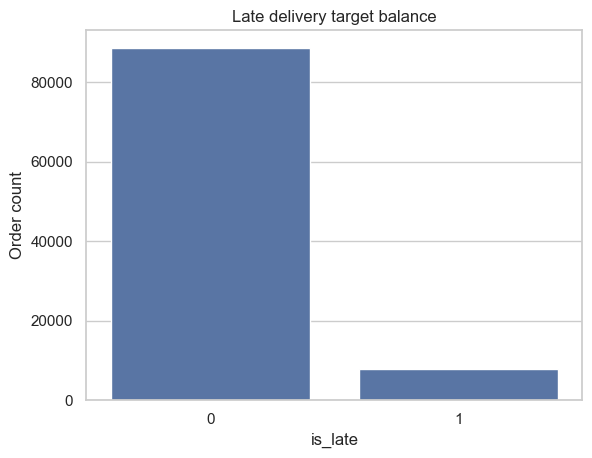

In [15]:
ax = sns.countplot(data=dataset, x="is_late")
ax.set(title="Late delivery target balance", xlabel="is_late", ylabel="Order count")
plt.show()

## Plot 2: Late rate by customer state
Limit to the most common states so the chart stays readable.

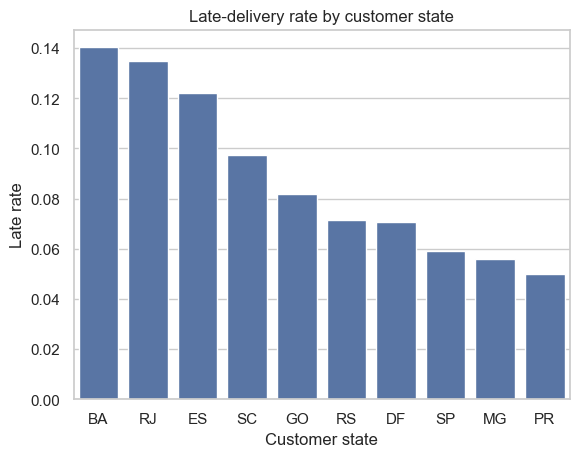

In [16]:
top_states = dataset['customer_state'].value_counts().head(10).index
state_rates = (
    dataset.loc[dataset['customer_state'].isin(top_states)]
    .groupby('customer_state', as_index=False)['is_late']
    .mean()
    .sort_values('is_late', ascending=False)
)

ax = sns.barplot(data=state_rates, x='customer_state', y='is_late')
ax.set(title='Late-delivery rate by customer state', xlabel='Customer state', ylabel='Late rate')
plt.show()

## Plot 3: Estimated delivery window vs. target
This checks whether tighter promised windows are associated with more delay risk.

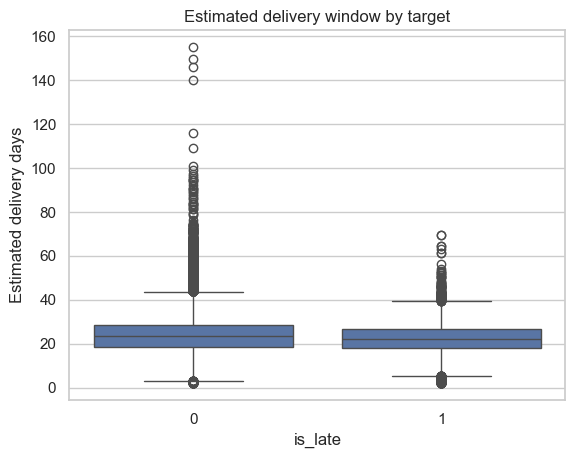

In [17]:
ax = sns.boxplot(data=dataset, x='is_late', y='estimated_delivery_days')
ax.set(title='Estimated delivery window by target', xlabel='is_late', ylabel='Estimated delivery days')
plt.show()

## Plot 4: Payment type and late rate
This can surface simple operational or customer-behavior patterns.

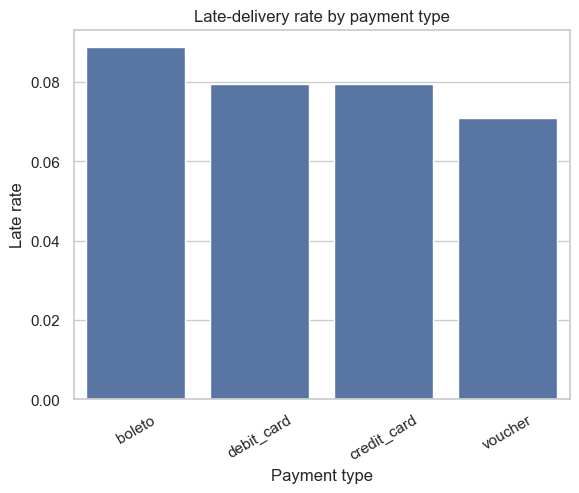

In [18]:
payment_rates = (
    dataset.groupby('payment_type_mode', as_index=False)['is_late']
    .mean()
    .sort_values('is_late', ascending=False)
)

ax = sns.barplot(data=payment_rates, x='payment_type_mode', y='is_late')
ax.set(title='Late-delivery rate by payment type', xlabel='Payment type', ylabel='Late rate')
plt.xticks(rotation=30)
plt.show()

## Plot 5: Price distribution by target
This is a quick way to see whether larger baskets behave differently.

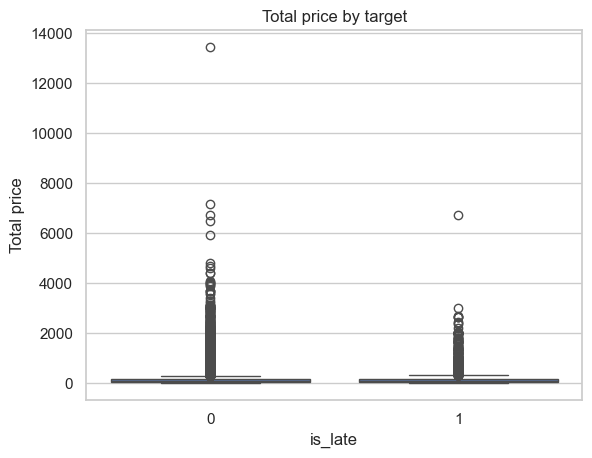

In [19]:
ax = sns.boxplot(data=dataset, x='is_late', y='total_price')
ax.set(title='Total price by target', xlabel='is_late', ylabel='Total price')
plt.show()

## Temporal patterns

The iteration-2 results showed a large drop when switching from a random stratified split to a chronological split. That is a symptom of time-dependent structure in the target: if the late-delivery rate shifts across weeks or months, a random split lets the model see the future while training. The plots below quantify that drift so the gap is auditable.

In [20]:
import pandas as pd

temporal = dataset.copy()
temporal['purchase_ts'] = pd.to_datetime(temporal['order_purchase_timestamp'])
temporal = temporal.sort_values('purchase_ts').reset_index(drop=True)
temporal['year_month'] = temporal['purchase_ts'].dt.to_period('M').astype(str)
temporal['iso_year_week'] = temporal['purchase_ts'].dt.strftime('%G-W%V')
temporal['weekday'] = temporal['purchase_ts'].dt.day_name()
temporal['hour'] = temporal['purchase_ts'].dt.hour
split_index = int(len(temporal) * 0.8)
holdout_start = temporal.loc[split_index, 'purchase_ts']
train_late_rate = temporal.loc[: split_index - 1, 'is_late'].mean()
test_late_rate = temporal.loc[split_index:, 'is_late'].mean()
print(f'Rows with purchase_ts: {temporal["purchase_ts"].notna().sum():,}')
print(f'Window: {temporal["purchase_ts"].min()} -> {temporal["purchase_ts"].max()}')
print(f'Chronological holdout starts: {holdout_start}')
print(f'Train late rate: {train_late_rate:.2%} | Test late rate: {test_late_rate:.2%}')

Rows with purchase_ts: 96,470
Window: 2016-09-15 12:16:38 -> 2018-08-29 15:00:37
Chronological holdout starts: 2018-05-26 18:18:03
Train late rate: 8.82% | Test late rate: 5.29%


### Late rate by purchase month

Use this to spot regime shifts. A flat line means the chronological split should behave like the random split; a rising or spiking line means the random split was leaking future information backwards.

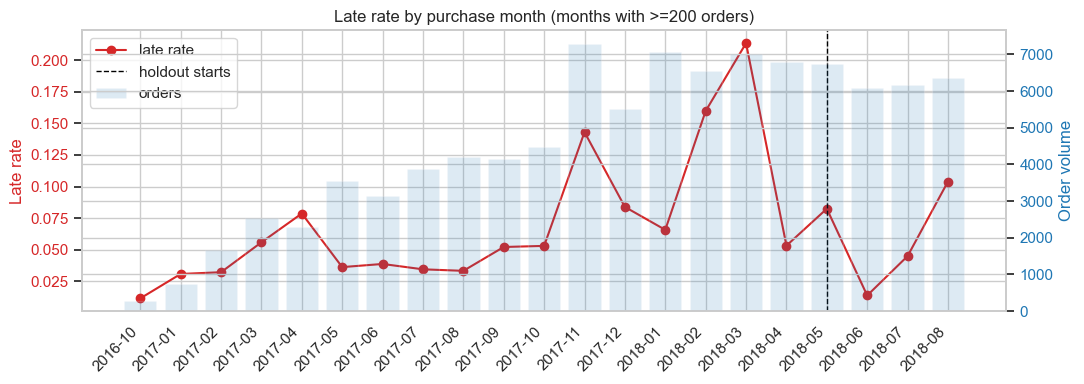

In [21]:
monthly = (
    temporal.groupby('year_month')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
    .sort_values('year_month')
    .reset_index(drop=True)
)
monthly = monthly[monthly['orders'] >= 200].reset_index(drop=True)
holdout_month = holdout_start.to_period('M').strftime('%Y-%m')
x_positions = list(range(len(monthly)))

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(x_positions, monthly['late_rate'], marker='o', color='tab:red', label='late rate')
if holdout_month in monthly['year_month'].values:
    holdout_idx = monthly.index[monthly['year_month'] == holdout_month][0]
    ax1.axvline(holdout_idx, color='black', linestyle='--', linewidth=1, label='holdout starts')
ax1.set_ylabel('Late rate', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(monthly['year_month'], rotation=45, ha='right')
ax2 = ax1.twinx()
ax2.bar(x_positions, monthly['orders'], alpha=0.15, color='tab:blue', label='orders')
ax2.set_ylabel('Order volume', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Late rate by purchase month (months with >=200 orders)')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
fig.tight_layout()
plt.show()

### Late rate by ISO week

A finer-grained view to see whether month-level smoothing is hiding short-lived spikes (e.g. Black Friday, carrier strikes).

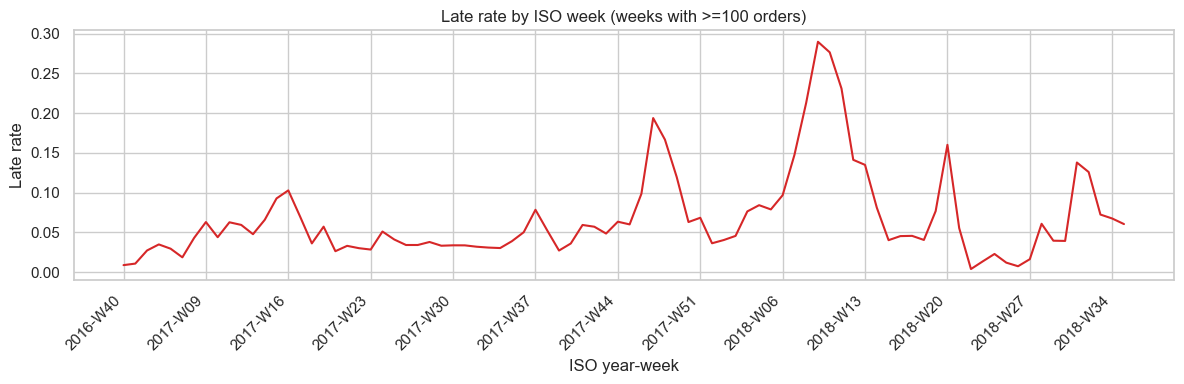

In [22]:
weekly = (
    temporal.groupby('iso_year_week')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)
weekly = weekly[weekly['orders'] >= 100].sort_values('iso_year_week')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly['iso_year_week'], weekly['late_rate'], color='tab:red')
ax.set_title('Late rate by ISO week (weeks with >=100 orders)')
ax.set_ylabel('Late rate')
ax.set_xlabel('ISO year-week')
n = len(weekly)
tick_positions = list(range(0, n, max(1, n // 12)))
ax.set_xticks(tick_positions)
ax.set_xticklabels(weekly['iso_year_week'].iloc[tick_positions], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Late rate by weekday and purchase hour

Intra-week and intra-day patterns. If these are flat, cyclical features add little; if they vary, they are cheap signal.

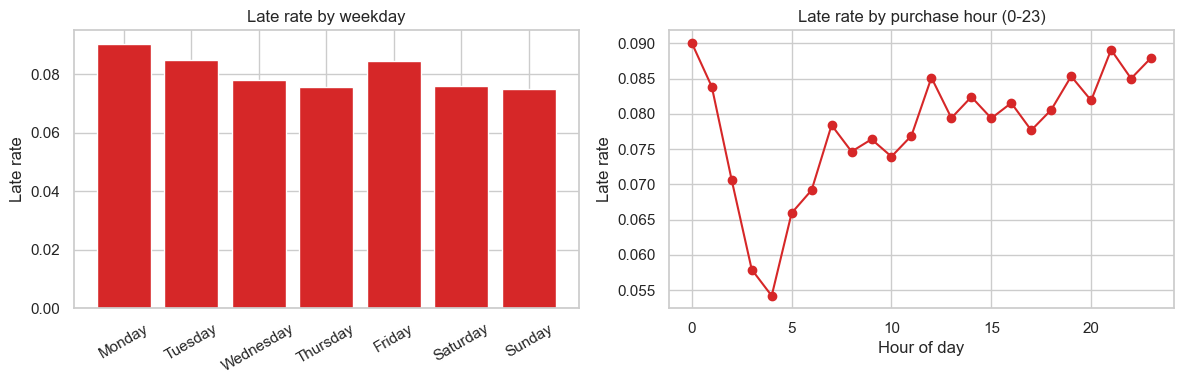

In [23]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = (
    temporal.groupby('weekday')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reindex(weekday_order)
    .reset_index()
)
hourly = (
    temporal.groupby('hour')
    .agg(orders=('is_late', 'size'), late_rate=('is_late', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(dow['weekday'], dow['late_rate'], color='tab:red')
axes[0].set_title('Late rate by weekday')
axes[0].set_ylabel('Late rate')
axes[0].tick_params(axis='x', rotation=30)
axes[1].plot(hourly['hour'], hourly['late_rate'], marker='o', color='tab:red')
axes[1].set_title('Late rate by purchase hour (0-23)')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Late rate')
plt.tight_layout()
plt.show()

### Estimated delivery window by month

The most important feature in the iteration-2 model is `estimated_delivery_days`. If the promised window itself shifts over time, that alone explains part of the chronological-split drop: the model learned the old regime's promised windows and is being evaluated against a shifted one.

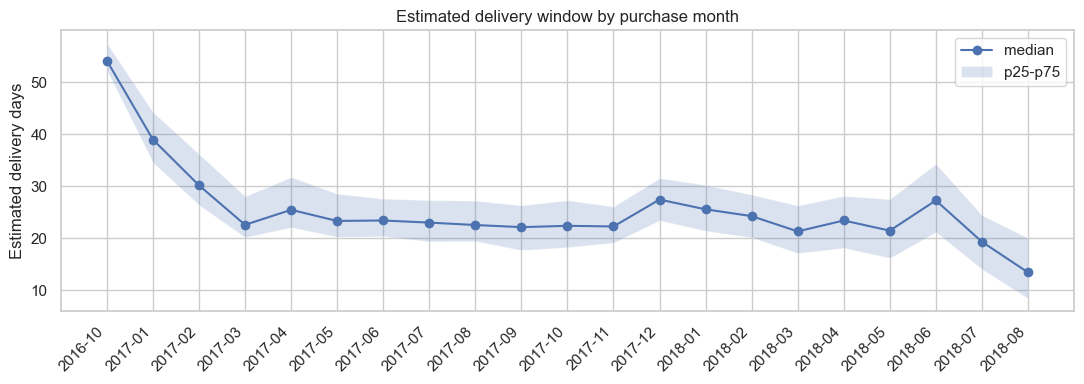

In [24]:
window_by_month = (
    temporal.groupby('year_month')
    .agg(
        orders=('estimated_delivery_days', 'size'),
        median_window=('estimated_delivery_days', 'median'),
        p25=('estimated_delivery_days', lambda s: s.quantile(0.25)),
        p75=('estimated_delivery_days', lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
window_by_month = window_by_month[window_by_month['orders'] >= 200]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(window_by_month['year_month'], window_by_month['median_window'], marker='o', label='median')
ax.fill_between(
    window_by_month['year_month'],
    window_by_month['p25'],
    window_by_month['p75'],
    alpha=0.2,
    label='p25-p75',
)
ax.set_title('Estimated delivery window by purchase month')
ax.set_ylabel('Estimated delivery days')
ax.set_xticks(range(len(window_by_month)))
ax.set_xticklabels(window_by_month['year_month'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

### Why the random split looked strong and the chronological split dropped

Read the plots above together:

1. **Monthly late rate drifts.** The random stratified split pulls orders from every month into both train and test, so the model implicitly learns per-month base rates and is then evaluated on orders drawn from the same months it trained on. The chronological split holds out the *final* 20% of months entirely - a harder and more honest task.
2. **Promised windows drift too.** `estimated_delivery_days` is the strongest feature, and if Olist tightened or widened its promised windows across the period, the train-time distribution of that feature does not match the holdout period.
3. **Short-lived spikes exist.** The ISO-week view typically shows weeks with 2-3x the average late rate. A random split lets those weeks appear in train; a chronological split does not.

Together, these three effects likely explain much of the gap between iteration 1 (AP 0.305, random) and iteration 2 (AP 0.082, chronological). The chronological number is the one to trust; the random number was an artifact of temporal leakage.

## Temporal takeaway
- The late-delivery base rate is not stationary over time: the chronological holdout period has a lower late rate than the earlier training window.
- `estimated_delivery_days` shifts by month too, so the model is not seeing the same promised-window distribution at train and test time.
- That makes the random split artificially easy and the chronological split the evaluation to trust.

## Notes to write after the first pass
- What is the late-delivery base rate?
- Which segments look riskier?
- Which features should definitely stay for the first model?
- Which features should be excluded because of leakage or low trust?